# AP 155 Lab Exercise
---
## Exercise 7: Matrices (Eigenfunctions and Eigenvalues of a Hamiltonian)

_Instructions_: 
- **Report figure:**
    - Plot 1: the lowest energy states shifted by their eigenvalues **alongside** $V(x)$ as a function of $x$. Include both bound and unbound states.
    - Plot 2: the calculated eigenvalues $E_n$ as a function of $n$. Show where quasi-degeneracy appears.
- **Report discussion**:
    - Explain what the main diagonal elements and off-diagonal elements in $\hat{T}$ represent.
    - Discuss the results you obtained in the figures.
    - In your implementation, is it better to use `eigh()` or `eig()`?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Baculo, Ezira Lojelle C.
- _Student No._: 2024-11845
- _Section_: THR-TX-3

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

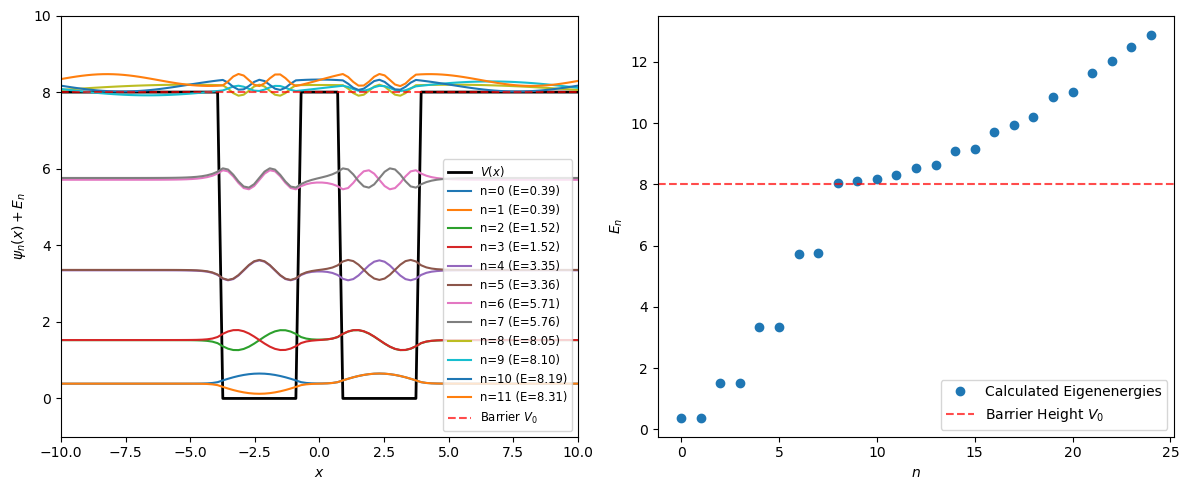

In [135]:
fig1

**Figure 1**. The first plot displays the lowest computed eigenstates shifted by their eigenvalues and superimposed on the finite double-square-well potential. States below $V_0$ are bound, whereas states above $V_0$ are unbound. The second plot displays the corresponding eigenvalues in relation to the state index. The small even/odd energy differences in successive pairs show quasi-degeneracy due to the weak interaction between the two wells.


### Report discussion

(1) The elements on the main diagonal of the finite-difference kinetic-energy matrix contain the local term $\hbar^2/[m(\Delta x)^2]$. The two adjacent off-diagonals have the coupling terms $-\hbar^2/[2m(\Delta x)^2]$ linking each grid point to its closest neighbors. These off-diagonal elements result from the central finite-difference approximation of $\psi''(x)$ and represent the spatial variation of the wave function.
\
\
(2) For the harmonic oscillator, the calculated energies closely match $E_n=\hbar\omega(n+1/2)$, confirming the Hamiltonian construction. For the finite double well, the low-energy states occur in almost degenerate pairs because each state can be formed from combinations of wave functions localized in the left and right wells. The lowest eight states are bound for the chosen $V_0=5$, while higher states become unbound. Increasing the barrier height causes the paired energy differences approach zero, reproducing the expected degeneracy of two independent wells.
\
\
(3) `eigh()` is favored since the Hamiltonian matrix is a real symmetric matrix (Hermitian in the broader quantum-mechanical case). It takes advantage of that structure, returns real eigenvalues, and generates orthonormal eigenvectors with improved numerical performance compared to treating the issue as a standard matrix with `eig()`.


### Other comments

- Sorry, sir. Nyehehehehe. 
- Note to self: Bakit ba ako nasa NIP??? 
- I hate matrices fr fr. 
- 🥲🥲🥲

#### Disclosure of AI Use:

I acknowledge the use of Gemini (accessed October 2026) to generate a first draft of the algorithms. All AI-assisted suggestions were reviewed and revised with the help of the references provided in the lecture and researched to ensure accuracy and clarity of meaning.

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Problem: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=E_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
} \tag{1} 
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a) Potential matrix construction**  
- Consider the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$.
- Generate $N=100$ uniformly distributed over the interval $-10 < x < 10$ and save this array as `x_pos`
- Evaluate $V(x)$ at these points and save the result as `pot_array`
- From `pot_array`, construct the corresponding $N \times N$ diagonal matrix $\hat{V}$ as defined in Eq. $(1)$.

In [84]:
def potential_matrix(N=100, m=1.0, omega=0.8):
    """
    Return the harmonic-oscillator potential matrix on the interior grid.
    """
    # N uniformly space interior points in (-10,10)
    x_pos = np.linspace(-10, 10, N)

    # Harmonic-oscillator potential
    pot_array = 0.5 * m * (omega**2) * x_pos**2

    # Diagonal potential-energy matrix
    V_hat = np.diag(pot_array)

    return x_pos, pot_array, V_hat

x_pos, pot_array, V_hat = potential_matrix()

# Print the shape to verify
print("Shape of x_pos:", x_pos.shape)
print("Shape of pot_array:", pot_array.shape)
print("Shape of V_hat:", V_hat.shape)

Shape of x_pos: (100,)
Shape of pot_array: (100,)
Shape of V_hat: (100, 100)


**(b) Kinetic energy matrix derivation** 
- On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the central finite-difference approximation to the second derivative:

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$
where $\Delta x = x_{i+1} - x_i$ is the grid spacing between adjacent points.

- First, compute the vector result
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. 

- Show that the resulting kinetic energy operator $\hat{T}$ takes the form of an $N \times N$ tridiagonal matrix:

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix} \tag{2}
} 
$$

- In the report discussion, explain what the matrix elements represent for $\hat{T}$.

**(c) Hamiltonian function implementation** 
- Combine Eqs. $(1)$ and $(2)$ by writing a function `hamiltonian(x_pos, potential_array, mass)` that returns an $N\times N$ Hamiltonian matrix ($\hat{T}+\hat{V}$) given `x_pos` and `potential_array` which are both $N \times 1$ arrays (column vectors), while `mass` is a scalar.
- Inputs:
    - `x_pos`: 1D array of $N$ position grid points.
    - `potential_array`: 1D array of $N$ potential energy values evaluated at `x_pos`.
    - `mass`: Scalar representing particle mass $m$.
    - Assume natural units where $\hbar = 1$.
- Output:
    - $N \times N$ Hamiltonian matrix.
- Hint: You may find `np.diag()` or `np.eye()` helpful for constructing diagonal and tridiagonal matrices efficiently.

In [81]:
def hamiltonian(x_pos, potential_array, mass):
    """
    Construct the Hamiltonian matrix using a finite-difference approximation.
    """
    # Grid spacing (assumes uniformly spaced grid points)
    dx = x_pos[1] - x_pos[0]

    # Number of grid points.
    n = x_pos.size

    """
    Construct the finite-difference kinetic-energy matrix
    With hbar = 1: T = -(1 / 2m) d^2/dx^2
    """
    
    # The second-derivative matrix has 2 on the diagonal and -1 on the first upper/lower diagonals
    kinetic = (
        np.diag(np.full(n, 2.0))
        - np.diag(np.ones(n - 1), 1)
        - np.diag(np.ones(n - 1), -1)
    ) / (2 * mass * dx**2)

    # Potential-energy matrix
    potential = np.diag(potential_array)

    # Hamiltonian: H = T + V
    return kinetic + potential

**(d) Sanity check with harmonic oscillator system**
- Test your `hamiltonian()` function on the harmonic oscillator potential $V(x) = \frac{1}{2}m\omega^2 x^2$ with $m = 1$, $\hbar = 1$, and $\omega = 0.8$.
- Compute the eigenvalues $E_n$ and eigenvectors $\psi_n(x)$ using `np.linalg.eigh()` or `np.linalg.eig()`.
- Extract the first $5$ lowest-energy eigenstates ($n = 0, 1, 2, 3, 4$).
- Plot each wave function shifted vertically by its corresponding energy eigenvalue:$f_n(x) = \psi_n(x) + E_n$ and overlay the potential curve $V(x)$ on the same plot to illustrate how the wave functions sit within the potential well.
- Also plot, for each $n$, the calculated eigenvalues together with the theoretical value of
$$ E_n = \hbar \omega \left( n + \frac{1}{2}\right).$$
- Your plots should look something like below

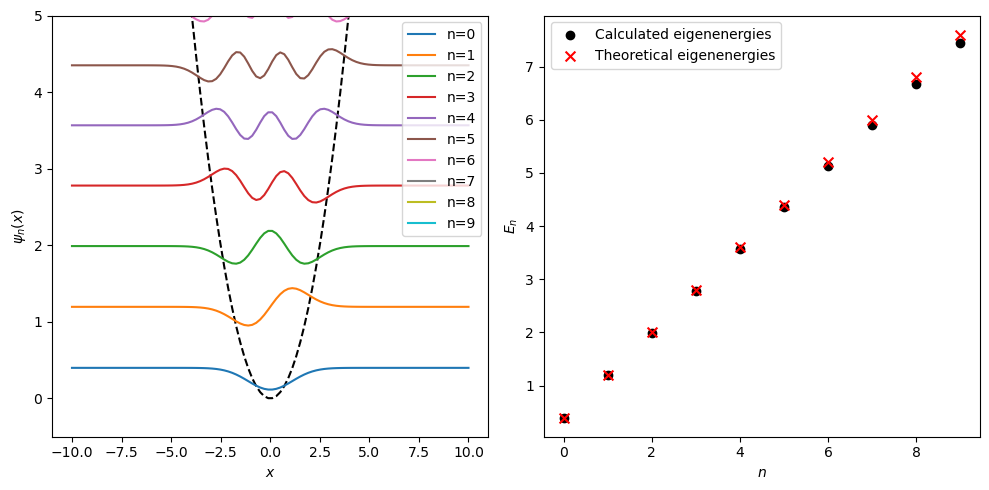

In [103]:
# Calculate Hamiltonian for the Harmonic Oscillator
H_ho = hamiltonian(x_pos, pot_array, m)

# Solve the eigenvalue problem
eigenvalues, eigenvectors = np.linalg.eigh(H_ho)

# Define the theoretical eigenenergies
n_vals = np.arange(10)
theo_energies = omega * (n_vals + 0.5)

# Normalize wavefunctions (ensuring unit normalization on the discrete grid with grid spacing dx)
dx = x_pos[1] - x_pos[0]
eigenvectors_normalized = eigenvectors / np.sqrt(dx)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot 1: Wavefunctions shifted by their energies and the potential well
ax1.plot(x_pos, pot_array, 'k--')
for n in range(10):
    ax1.plot(x_pos, 0.4 * eigenvectors_normalized[:, n] + eigenvalues[n], label=f"n={n}")

ax1.set_ylim(-0.5, 5.0)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$\psi_n(x)$")
ax1.legend(loc="upper right", ncol=1)

# Plot 2: Calculated vs Theoretical Eigenvalues
ax2.scatter(n_vals, eigenvalues[:10], color='black', marker='o', label="Calculated eigenenergies", zorder=3)
ax2.scatter(n_vals, theo_energies, color='red', marker='x', s=50, label="Theoretical eigenenergies", zorder=4)
ax2.set_xlabel("$n$")
ax2.set_ylabel("$E_n$")
ax2.legend()

plt.tight_layout()
plt.show()

**(e) [REPORT FIGURE] Finite double-Square Well Potential**
- Test your `hamiltonian()` function for a particle in a symmetric double-square well potential defined by:
  $$
  V(x) = 
  \begin{cases} 
  V_0 & \text{if } 0 \le \vert{}x\vert{} < \frac{a}{2} \quad (\text{central barrier}) \\ 
  0 & \text{if } \frac{a}{2} \le \vert{}x\vert{} < \frac{a}{2} + W \quad (\text{potential wells}) \\ 
  V_0 & \text{if } \vert{}x\vert{} \ge \frac{a}{2} + W \quad (\text{outer walls}) 
  \end{cases} \tag{3}$$
  where $a$ is the central barrier width, $W$ is the width of each well, and $V_0$ is the barrier height.
- Choose arbitrary and appropriate values for parameters $V_0$, $a$, and $W$ ($a<W<L$).
- Create a function that calculates the potential across $x$ using Eq. $(3)$.
- Calculate the eigenvalues and eigenvectors. Use `x_pos` from (a) as the spatial dimensions.
- Generate plots similar to the previous sub-item:
    - Plot 1: the lowest energy states shifted by their eigenvalues **alongside** $V(x)$. Make sure to illustrate both bound and unbound states. Explain what you see.
    - Plot 2: the calculated eigenvalues $E_n$ as a function of $n$. (No closed-form expressions exists for this potential)
- Sanity check: if you raise $V_0$ to a very high number (to simulate infinite square wells), you should see exact degeneracy.

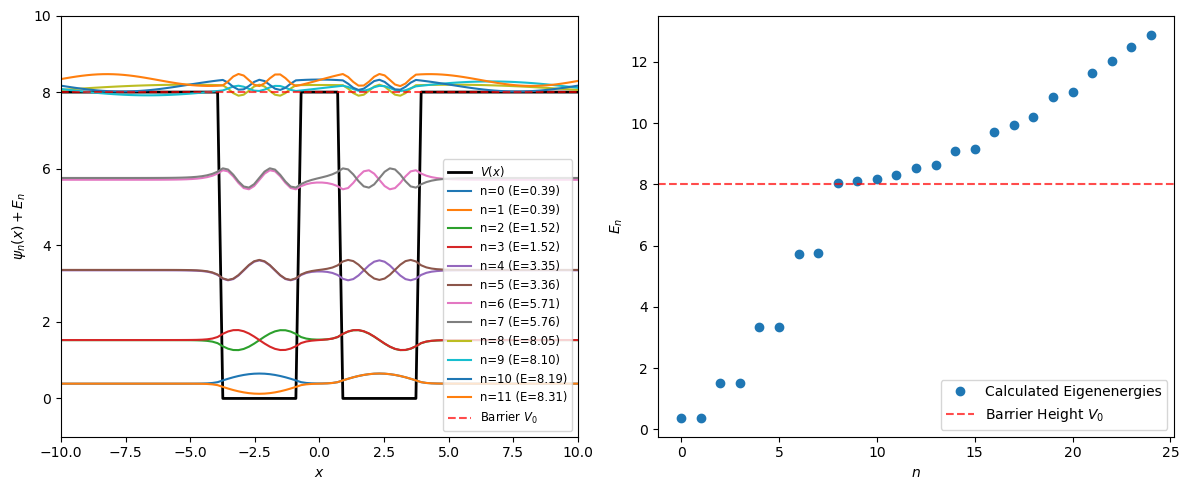

In [134]:
def double_well_potential(x, V0, a, W):
    """
    Computes the symmetric double-square well potential V(x) based on Eq. (3).
    """
    V = np.zeros_like(x)
    abs_x = np.abs(x)
    
    # Central barrier: 0 <= |x| < a/2
    mask_barrier = abs_x < (a / 2.0)
    V[mask_barrier] = V0
    
    # Potential wells: a/2 <= |x| < a/2 + W
    mask_wells = (abs_x >= (a / 2.0)) & (abs_x < (a / 2.0 + W))
    V[mask_wells] = 0.0
    
    # Outer walls: |x| >= a/2 + W
    mask_outer = abs_x >= (a / 2.0 + W)
    V[mask_outer] = V0
    
    return V

# Parameters
V0 = 8.0   # Barrier height
a = 1.5    # Central barrier width
W = 3.0    # Width of each well
mass = 1.0

# Compute potential
V_double = double_well_potential(x_pos, V0, a, W)

# Compute Hamiltonian
H_double = hamiltonian(x_pos, V_double, mass)

# Solve the eigenvalues and eigenvectors
eigvals_double, eigvecs_double = np.linalg.eigh(H_double)

# Normalize wavefunctions
dx = x_pos[1] - x_pos[0]
eigvecs_double_norm = eigvecs_double / np.sqrt(dx)


fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Wavefunctions (Bound and Unbound) shifted by energies alongside V(x)
ax1.plot(x_pos, V_double, 'k-', linewidth=2, label="$V(x)$")

# Select first 12 states to show both bound (E < V0) and unbound (E > V0) states
n_plot = 12
for n in range(n_plot):
    psi_shifted = 0.5 * eigvecs_double_norm[:, n] + eigvals_double[n]
    line = ax1.plot(x_pos, psi_shifted, label=f"n={n} (E={eigvals_double[n]:.2f})")
    
ax1.axhline(V0, color='red', linestyle='--', alpha=0.7, label="Barrier $V_0$")
ax1.set_xlim(-10, 10)
ax1.set_ylim(-1.0, 10.0)
ax1.set_xlabel("$x$")
ax1.set_ylabel("$\psi_n(x) + E_n$")
ax1.legend(loc="lower right", ncol=1, fontsize='small')

# Plot 2: Eigenvalues as a function of n showcasing quasi-degeneracy for bound states
n_vals_all = np.arange(len(eigvals_double))
ax2.plot(n_vals_all[:25], eigvals_double[:25], 'o', label="Calculated Eigenenergies")
ax2.axhline(V0, color='red', linestyle='--', alpha=0.7, label="Barrier Height $V_0$")
ax2.set_xlabel("$n$")
ax2.set_ylabel("$E_n$")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

Your program should generate behavior simlar to the figures below (Sakurai, Modern Quantum Mechanics). Illustrations of wavefunction across position.

<img src='figures/sakurai_finiteDoubleSquare.png' width=67%>

<img src='figures/sakurai_infiniteDoubleSquare.png' width=67%>

**(f) Eigenvalue decomposition**

Numerically verify that your computed Hamiltonian matrix $\mathbf{H}$, eigenvector matrix $\mathbf{V}$ (where columns are eigenvectors), and diagonal eigenvalue matrix $\mathbf{D} = \text{diag}(E_0, E_1, \dots, E_{N-1})$ satisfy (up to some precision) the decomposition:$$\mathbf{H} = \mathbf{V}\mathbf{D} \mathbf{V}^{-1}.$$

In [129]:
D = np.diag(eigvals_double)

# The column vectors of eigvecs_double form the matrix V
V = eigvecs_double

# Compute V * D * V^-1
# Since V is orthogonal (since H is symmetric), V^-1 is equal to V.T
V_inv = np.linalg.inv(V)
H_reconstructed = V @ D @ V_inv

# Verify that H_reconstructed is numerically close to H_double
is_close = np.allclose(H_double, H_reconstructed, atol=1e-10)

# Compute the maximum absolute difference as an error metric
max_diff = np.max(np.abs(H_double - H_reconstructed))

print("Is H and V * D * V^-1 numerically identical within a precision of 1e-10?", is_close)
print(f"Maximum absolute discrepancy: {max_diff:.2e}")

Is H and V * D * V^-1 numerically identical within a precision of 1e-10? True
Maximum absolute discrepancy: 3.20e-14


#### Problem code summary

The script converts the one-dimensional Schrödinger equation into a discrete form on a uniform spatial grid, resulting in the kinetic-energy operator being represented as a tridiagonal finite-difference matrix, while the potential-energy operator is represented as a diagonal matrix. The `hamiltonian()` function merges these two matrices to create $H=T+V$. Then, `np.linalg.eigh()` addresses the symmetric eigenvalue issue, providing the energy levels along with the associated wave functions. The harmonic oscillator serves as a verification tool for its analytical energy spectrum. The same Hamiltonian framework is then applied on a finite symmetric double-square well to examine bound and unbound states, quasi-degenerate pairs, and the limit of degeneracy at high barriers. Ultimately, the eigendecomposition is confirmed numerically by reconstructing $H=VDV^{-1}$.


---
## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* [np.linalg.eigh](https://numpy.org/doc/2.3/reference/generated/numpy.linalg.eigh.html)
* [Exact Solutions of the Quantum Double-Square-Well Potential](https://www.researchgate.net/publication/281409877_Exact_Solutions_of_the_Quantum_Double-Square-Well_Potential#fullTextFileContent)
* [Modern Quantum Mechanics, see page 261](https://icourse.club/uploads/files/65fb4c16648d2b93f82fe3271c3381c211f2f532.pdf)
* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)